In [329]:
import os
nnUNet_raw = "data/nnUNet_raw"
nnUNet_results = "data/nnUNet_results/nnunet"
nnUNet_preprocessed = "data/nnUNet_preprocessed"

os.environ["nnUNet_raw"] = nnUNet_raw
os.environ["nnUNet_results"] = nnUNet_results
os.environ["nnUNet_preprocessed"] = nnUNet_preprocessed
os.environ["nnUNet_compile"] = "false"

In [330]:
import json
import random
import numpy as np
import torch
import torch.nn as nn
from tqdm import tqdm
from batchgenerators.utilities.file_and_folder_operations import join
from nnunetv2.run.run_training import get_trainer_from_args
from nnunetv2.inference.predict_from_raw_data import nnUNetPredictor
from tqdm import tqdm
from score_net import load_nnunet_model, center_crop_or_pad

In [331]:
from re import T
from types import SimpleNamespace

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

def get_dataset_name(dataset_id):
    dataset_id = str(dataset_id).zfill(3)
    dataset_name = [
        d for d in os.listdir(nnUNet_raw)
        if d.startswith(f"Dataset{dataset_id}") and os.path.isdir(join(nnUNet_raw, d))
    ]
    if len(dataset_name) != 1:
        raise RuntimeError(f"Found {len(dataset_name)} datasets with id {dataset_id}, expected 1")
    return dataset_name[0]

def get_num_input_channels(dataset_name):
    with open(join(nnUNet_raw, dataset_name, "dataset.json"), "r") as f:
        dataset_json = json.load(f)
    return len(dataset_json["channel_names"])

def get_args(train_dataset_id, cfg, batch_size, use_pretrained):
    args = dict(
        train_dataset_id = train_dataset_id,
        plans = "nnUNetPlans",
        trainer = "nnUNetTrainer_100epochs",
        cfg = cfg,
        fold = "0",
        seed = 12,
        metrics = "swap,naswot",
        split = "Tr",
        use_pretrained = use_pretrained,
        encoder_only = False,
        debug_activations = False,
        debug_bins = 100,
        debug_max_samples = 200000,
        save_batch_jacobian = False,
        batch_size = batch_size,
        naswot_breakdown = False,
        out_dir = "results/nas_metrics",
    )

    return SimpleNamespace(**args)

In [332]:
cfgs = [
    "2d_tiny1",
    "2d_tiny2",
    "2d_tiny4",
    "2d_tiny8",
    "2d_tiny16",
    "2d_tiny32",
    "2d_tiny64",
    "2d_tiny128",
    "2d_tiny256",
    "2d",
]

train_dataset_id = "302"
cfg = cfgs[0]
batch_size = 1
use_pretrained = True
args = get_args(train_dataset_id, cfg, batch_size, use_pretrained)
set_seed(args.seed)

metric_set = {m.strip().lower() for m in args.metrics.split(",") if m.strip()}
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model, dataset_name, loss_fn, data_loader, num_train, mini_batch_size, patch_size = load_nnunet_model(
    args.train_dataset_id,
    args.plans,
    args.trainer,
    args.cfg,
    args.fold,
    device,
    pretrained=args.use_pretrained,
    num_cases=args.batch_size,
)
# model.eval()
for i, batch in tqdm(enumerate(data_loader), total=args.batch_size if args.batch_size != "all" else num_train):
    imgs = batch['data']
    meta = batch['ofile']
    imgs = imgs.permute(1, 0, 2, 3)
    orig_shape = imgs.shape
    imgs = center_crop_or_pad(imgs, patch_size, pad_value=0)
    imgs = imgs.to(device)
    print("imgs: ", imgs.shape)

Using device: cuda:0

#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################



There are 1 cases in the source folder
I am processing 0 out of 1 (max process ID is 0, we start counting with 0!)
There are 1 cases that I would like to predict


100%|██████████| 1/1 [00:01<00:00,  1.94s/it]

imgs:  torch.Size([1, 1, 112, 112])


100%|██████████| 1/1 [00:02<00:00,  2.69s/it]


In [333]:
import re

activation_dict = {}

def register_forward_hook(name):
    def forward_hook(module, inp, out):
        activation_dict[name] = out.detach().cpu().numpy()
    return forward_hook

def remove_hooks(handles):
    for h in handles:
        h.remove()

def decoder_key(k):
    m = re.match(r"decoder\.stages\.(\d+)\.convs\.(\d+)\.conv", k)
    if m:
        stage = int(m.group(1))
        conv = int(m.group(2))
        return (1, -stage, conv)  # stages first (reverse=True): stage 3->0, conv 0->1
    m2 = re.match(r"decoder\.seg_layers\.(\d+)", k)
    if m2:
        return (0, int(m2.group(1)), 0)  # seg_layers at the end (smaller key)
    return (-1, 0, 0)  # other last


# target_module = nn.Conv2d
target_module = nn.InstanceNorm2d
# target_module = nn.LeakyReLU
handles = []
for name, m in model.named_modules():
    if isinstance(m, target_module):
        print(name, m)
        handles.append(m.register_forward_hook(register_forward_hook(name)))

target_module = target_module.__name__

encoder.stages.0.0.convs.0.norm InstanceNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
encoder.stages.0.0.convs.1.norm InstanceNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
encoder.stages.1.0.convs.0.norm InstanceNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
encoder.stages.1.0.convs.1.norm InstanceNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
encoder.stages.2.0.convs.0.norm InstanceNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
encoder.stages.2.0.convs.1.norm InstanceNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
encoder.stages.3.0.convs.0.norm InstanceNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
encoder.stages.3.0.convs.1.norm InstanceNorm2d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=False)
encoder.stages.4.0.convs.0.norm InstanceNorm2d(1, eps=1e-05, momentum=0.1, affin

pred:  (1, 112, 112)
img_path:  data/nnUNet_raw/Dataset302_EchoNet-Dynamic/imagesTr/EchoNet-Dynamic_4ch_3600_398_0000.png
img:  (1, 112, 112) 0 254
target:  (1, 1, 112, 112) [0 1]
img:  (112, 112, 1) 0 254


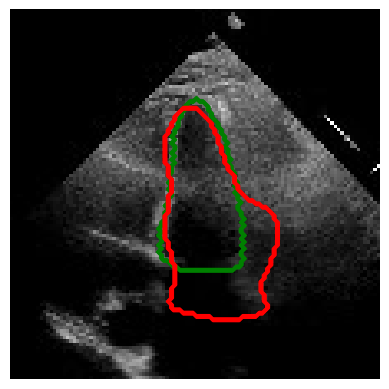

In [334]:
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image

model.eval()
output = model(imgs)
remove_hooks(handles)

pred = output.argmax(dim=1)
pred = pred.cpu().numpy()
print('pred: ', pred.shape)
if imgs.shape[1] == 1:
    img_path = join(nnUNet_raw, dataset_name, "imagesTr", f"{os.path.basename(meta)}_0000.png")
    img = np.array(Image.open(img_path))[None,...]
else:
    img = np.zeros((3, imgs.shape[2], imgs.shape[3]))
    for i in range(imgs.shape[1]):
        img_path = join(nnUNet_raw, dataset_name, "imagesTr", f"{os.path.basename(meta)}_{i:04d}.png")
        img[i] = np.array(Image.open(img_path))

target_path = join(nnUNet_raw, dataset_name, "labelsTr", f"{os.path.basename(meta)}.png")
target = np.array(Image.open(target_path))[None, None,...]
print("img_path: ", img_path)
print('img: ', img.shape, img.min(), img.max())
print("target: ", target.shape, np.unique(target))
img = center_crop_or_pad(torch.from_numpy(img), patch_size).numpy()
target = center_crop_or_pad(torch.from_numpy(target), patch_size).numpy()
img = img.transpose(1, 2, 0)
img = img.astype(np.uint8)
target = target.squeeze(0).squeeze(0)
print('img: ', img.shape, img.min(), img.max())
plt.imshow(img, cmap="gray" if img.shape[2] == 1 else None)
plt.contour(target, colors='green')
plt.contour(pred[0], colors='red')
plt.axis("off")
plt.show()

Saved activation histograms to results/analysis/activations_distribution/Dataset302_EchoNet-Dynamic/InstanceNorm2d/EchoNet-Dynamic_4ch_3600_398/2d_tiny1_dist.png


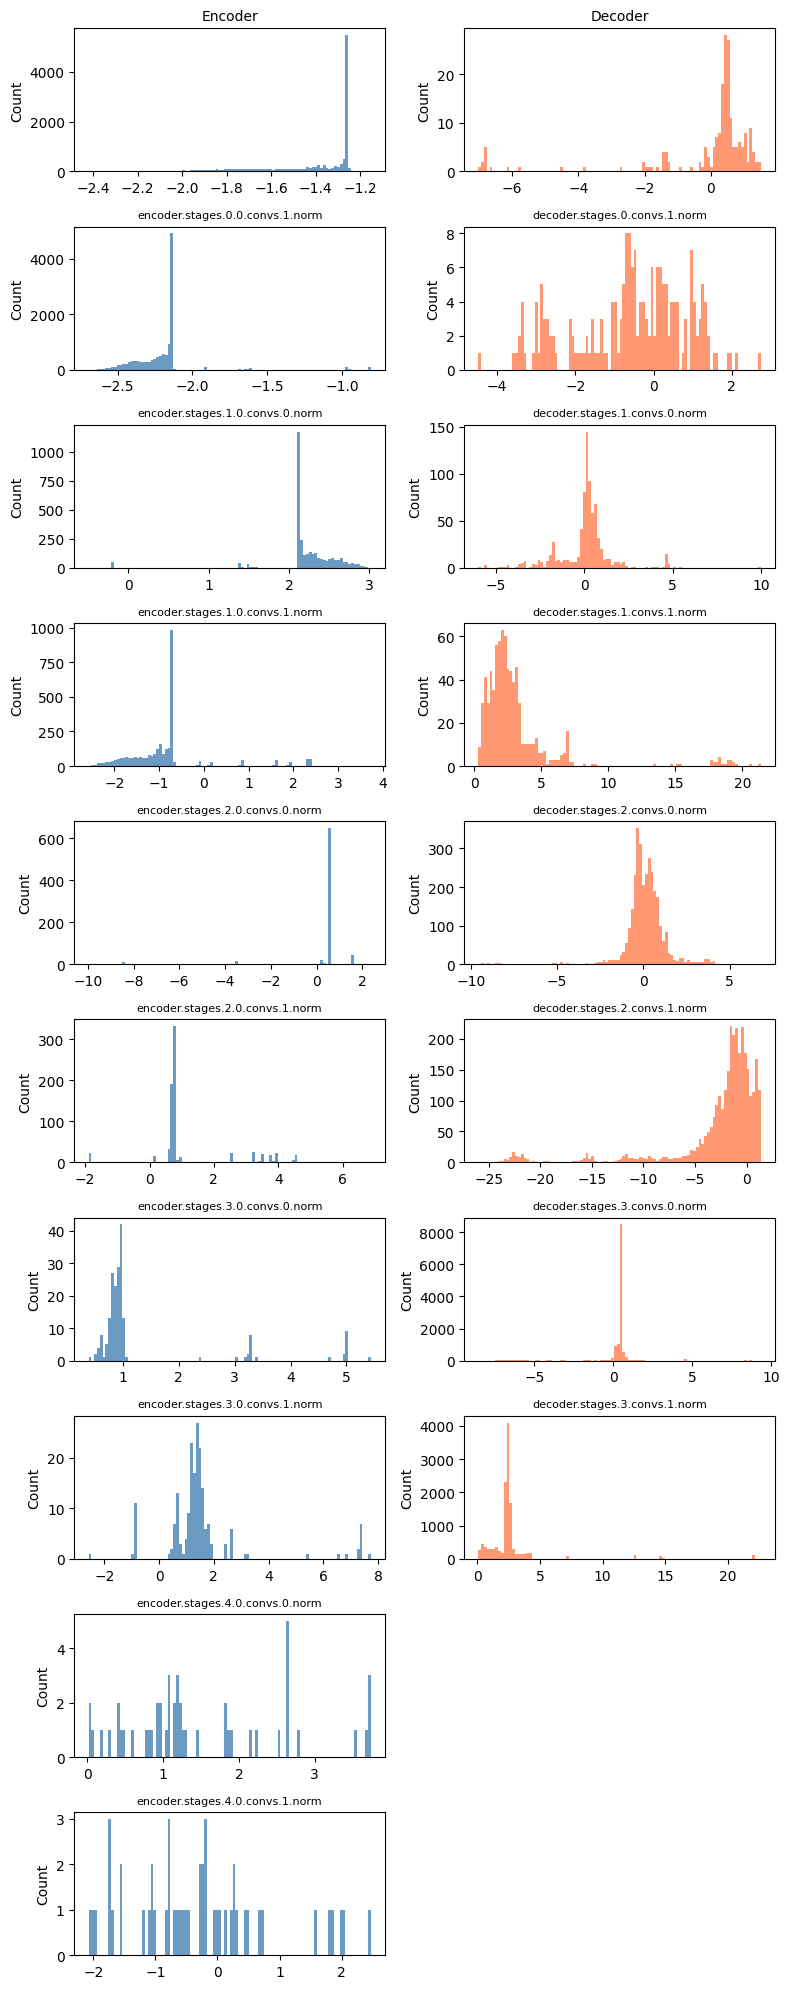

In [335]:
encoder_keys = [k for k in activation_dict.keys() if "encoder" in k]
decoder_keys = [k for k in activation_dict.keys() if "decoder" in k]
encoder_keys.sort()
decoder_keys = sorted(decoder_keys, key=decoder_key, reverse=True)

n_rows = len(encoder_keys)
fig, axes = plt.subplots(n_rows, 2, figsize=(8, 2 * n_rows))
if n_rows == 1:
    axes = axes.reshape(1, -1)

for i in range(n_rows):
    enc_key = encoder_keys[i]
    axes[i, 0].hist(activation_dict[enc_key].flatten(), bins=100, color='steelblue', alpha=0.8)
    axes[i, 0].set_title(enc_key, fontsize=8)
    axes[i, 0].set_ylabel('Count')
    if i < len(decoder_keys):
        dec_key = decoder_keys[i]
        axes[i, 1].hist(activation_dict[dec_key].flatten(), bins=100, color='coral', alpha=0.8)
        axes[i, 1].set_title(dec_key, fontsize=8)
        axes[i, 1].set_ylabel('Count')
    else:
        axes[i, 1].set_visible(False)

axes[0, 0].set_title('Encoder', fontsize=10)
axes[0, 1].set_title('Decoder', fontsize=10)

plt.tight_layout()

save_dir = f"results/analysis/activations_distribution/{dataset_name}/{target_module}/{os.path.basename(meta)}"
os.makedirs(save_dir, exist_ok=True)
save_path = join(save_dir, f"{cfg}_dist.png")
if not args.use_pretrained:
    save_path = save_path.replace(".png", "_at_init.png")
plt.savefig(save_path)
print(f"Saved activation histograms to {save_path}")
plt.show()

In [336]:
# encoder_keys = [k for k in activation_dict.keys() if "encoder" in k]
# decoder_keys = [k for k in activation_dict.keys() if "decoder" in k]
# encoder_keys.sort()
# decoder_keys = sorted(decoder_keys, key=decoder_key, reverse=True)

# save_dir = f"results/analysis/activations/{dataset_name}/{target_module}/{os.path.basename(meta)}_{cfg}"
# os.makedirs(save_dir, exist_ok=True)

# keys = encoder_keys + decoder_keys
# for i, key in enumerate(keys):
#     act = activation_dict[key]
#     print(key, act.shape)

#     n_cols = 8
#     n_rows = (act.shape[1] + 7) // 8  # ceiling: wrap to next row when channels > 8
#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(2 * n_cols, 2 * n_rows))
#     if n_rows == 1:
#         axes = axes.reshape(1, -1)
#     for ch in range(act.shape[1]):
#         r, c = ch // n_cols, ch % n_cols
#         axes[r, c].imshow(act[0, ch], cmap="gray")
#         axes[r, c].set_title(f'ch {ch}', fontsize=8)
#         axes[r, c].axis('off')
#     for idx in range(act.shape[1], n_rows * n_cols):
#         axes[idx // n_cols, idx % n_cols].set_visible(False)
#     # set suptitle
#     fig.suptitle(key, fontsize=14)
#     plt.tight_layout()
#     save_path = join(save_dir, f"{i:03d}_{key}.png")
#     if not args.use_pretrained:
#         save_path = save_path.replace(".png", "_at_init.png")
#     plt.savefig(save_path)
#     print(f"Saved activation images to {save_path}")
#     plt.close()
#     # plt.show()

In [337]:
# out = [act for act in activation_dict if "decoder.seg_layers" in act]
# pred = output.argmax(dim=1)
# pred = pred.cpu().numpy()
# print('pred: ', pred.shape)
# plt.imshow(pred[0])
# plt.axis("off")
# plt.show()
